````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/Verendeoplinmidden.py

```
```` 


# Voorbeeld verende oplegging midden

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting 1000*SingularityFunction(x, 0, -1)/17 - 2000*SingularityFunction(x, 3, -1)/17 + 1000*SingularityFunction(x, 6, -1)/17
Dwarskrachten -1000*SingularityFunction(x, 0, 0)/17 + 2000*SingularityFunction(x, 3, 0)/17 - 1000*SingularityFunction(x, 6, 0)/17
Reactiekrachten {R_3: 2250/17, R_6: 1000/17, R_0: 1000/17}
Moment -1000*SingularityFunction(x, 0, 1)/17 + 2000*SingularityFunction(x, 3, 1)/17 - 1000*SingularityFunction(x, 6, 1)/17
Hoeverdraaiing SingularityFunction(x, 0, 2)/136 - SingularityFunction(x, 3, 2)/68 + SingularityFunction(x, 6, 2)/136 - 9/136
Doorbuiging -9*x/136 + SingularityFunction(x, 0, 3)/408 - SingularityFunction(x, 3, 3)/204 + SingularityFunction(x, 6, 3)/408


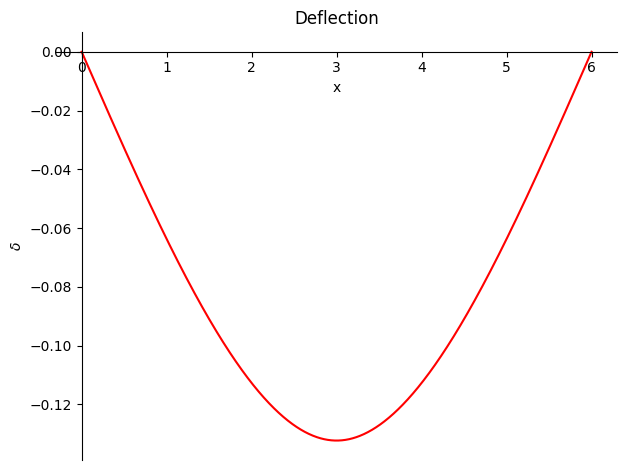

In [1]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols

#Omschrijving van de balk
R_3, R_0, R_6 = symbols(['R_3', 'R_0', 'R_6'])
b = Beam(6, 200, 20)
#belastingen
b.apply_load(R_0,0,-1)
b.apply_load(R_6,6,-1)
b.apply_load(R_3,3,-1)
b.apply_load(-250,3,-1)

b.bc_deflection = [(3,-R_3 / 1000), (0,0), (6,0)]
#b.apply_rotation_spring(6, 100)
b.solve_for_reaction_loads(R_0, R_3, R_6)
#berekeningen
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())
axes = b.plot_deflection()